# Exercise: Fashion MNIST Classification
## Your Task: Adapt the CNN model we've built to classify the Fashion MNIST dataset.

The Fashion MNIST dataset consists of 28×28 grayscale images of 10 fashion categories:

* 0: T-shirt/top
* 1: Trouser
* 2: Pullover
* 3: Dress
* 4: Coat
* 5: Sandal
* 6: Shirt
* 7: Sneaker
* 8: Bag
* 9: Ankle boot

## Steps:

* Load the Fashion MNIST dataset instead of regular MNIST
* Adapt the CNN model if necessary (you might want to use more filters or deeper architecture for this more complex dataset)
* Train and evaluate the model
* Visualize the results and compare with the digit classification results
* Hint: You can load Fashion MNIST using torchvision.datasets.FashionMNIST instead of datasets.MNIST.

In [142]:
## import

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor

import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


Vedo la doc del dataset [qui](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) e da varie ricerche scopro che è un dataset sviluppato dai ricercatori di **Zalando** come alternativa al dataset originale. Ha 70.000 img in scala di grigio, divise in 10 categorie. Ogni img è **28*28** pixel. Il set è diviso in training (60.000) e e test (10.0000).

Le categorie sono:

* T-shirt/top
* Trouser
* Pullover
* Dress
* Coat
* Sandal
* Shirt
* Sneaker
* Bag
* Ankle boot



In [143]:
# Definiamo una trasformazione per normalizzare le immagini
transform = transforms.Compose([
    transforms.ToTensor(),  # Converte le immagini in tensori (e scala i valori da 0-255 a 0-1)
    transforms.Normalize((0.28,), (0.35,))  # Usando valori calcolati
])

# Load the dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Define labels for FashionMNIST classes
fashion_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}



%|                                               | 0.00/26.4M [00:00<?, ?B/s]
%|▏                                      | 98.3k/26.4M [00:00<00:30, 872kB/s]
%|▋                                      | 492k/26.4M [00:00<00:11, 2.26MB/s]
%|█▎                                     | 885k/26.4M [00:00<00:08, 2.91MB/s]
%|█▋                                    | 1.21M/26.4M [00:00<00:08, 2.88MB/s]
%|██▎                                   | 1.64M/26.4M [00:00<00:07, 3.13MB/s]
%|██▊                                   | 2.00M/26.4M [00:00<00:07, 3.25MB/s]
%|███▍                                  | 2.36M/26.4M [00:00<00:07, 3.35MB/s]
%|███▉                                  | 2.72M/26.4M [00:00<00:06, 3.39MB/s]
%|████▍                                 | 3.11M/26.4M [00:01<00:06, 3.39MB/s]
%|████▉                                 | 3.47M/26.4M [00:01<00:06, 3.44MB/s]
%|█████▌                                | 3.83M/26.4M [00:01<00:06, 3.43MB/s]
%|██████▏                               | 4.26M/26.4M [00:01<00

## COntrollo la distribuzione delle classi

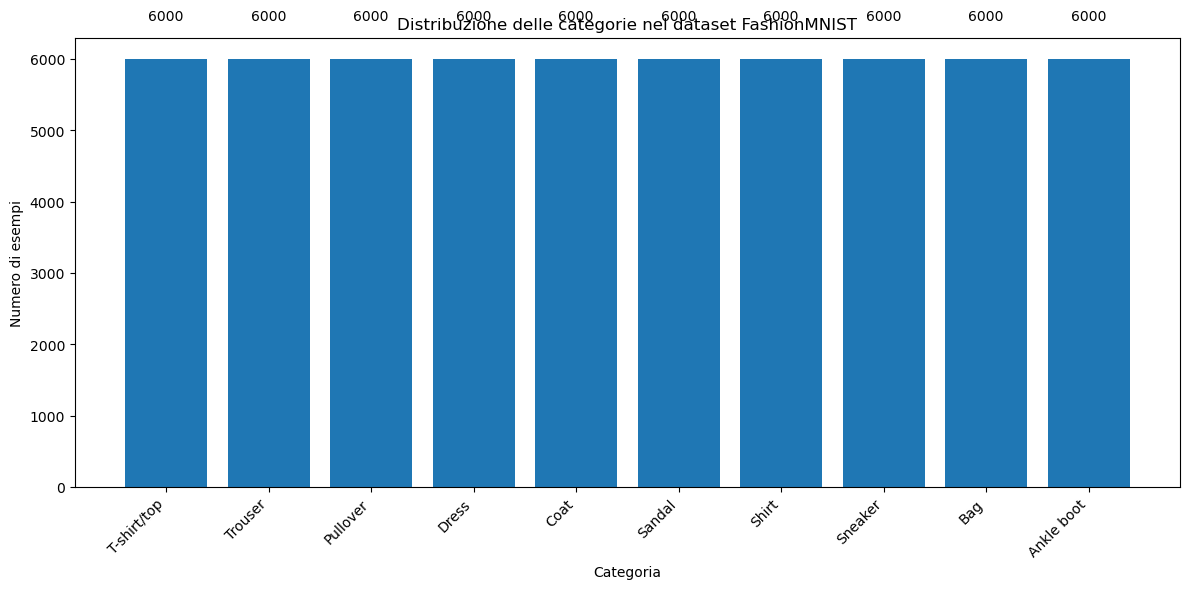

In [144]:
# Count occurrences of each class
label_counts = {}
for _, label in train_dataset:
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1

# Sort by label index
sorted_labels = sorted(label_counts.items())
categories = [fashion_labels[idx] for idx, _ in sorted_labels]
counts = [count for _, count in sorted_labels]

# Create a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(categories, counts)
plt.title('Distribuzione delle categorie nel dataset FashionMNIST')
plt.xlabel('Categoria')
plt.ylabel('Numero di esempi')
plt.xticks(rotation=45, ha='right')

# Add count numbers on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

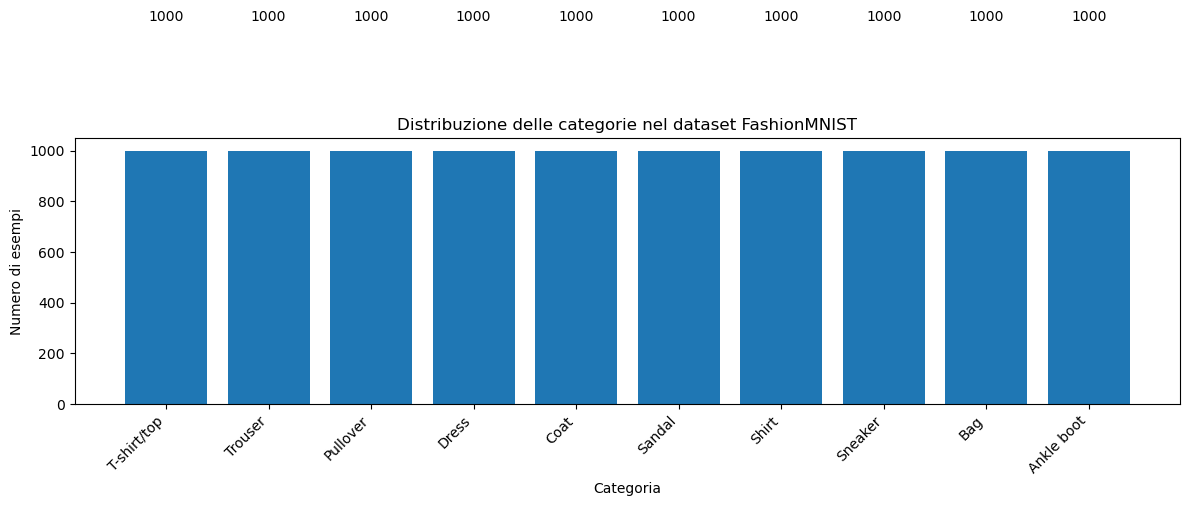

In [145]:
# Count occurrences of each class (in test data set)
label_counts = {}
for _, label in test_dataset:
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1

# Sort by label index
sorted_labels = sorted(label_counts.items())
categories = [fashion_labels[idx] for idx, _ in sorted_labels]
counts = [count for _, count in sorted_labels]

# Create a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(categories, counts)
plt.title('Distribuzione delle categorie nel dataset FashionMNIST')
plt.xlabel('Categoria')
plt.ylabel('Numero di esempi')
plt.xticks(rotation=45, ha='right')

# Add count numbers on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Verifico le informazioni recuperate:


Immagine 1:
  Forma (shape): torch.Size([1, 28, 28])
  Tipo di dati: torch.float32
  Valore minimo: -0.800000011920929
  Valore massimo: 2.057142972946167

Immagine 2:
  Forma (shape): torch.Size([1, 28, 28])
  Tipo di dati: torch.float32
  Valore minimo: -0.800000011920929
  Valore massimo: 2.057142972946167

Immagine 3:
  Forma (shape): torch.Size([1, 28, 28])
  Tipo di dati: torch.float32
  Valore minimo: -0.800000011920929
  Valore massimo: 2.057142972946167

Immagine 4:
  Forma (shape): torch.Size([1, 28, 28])
  Tipo di dati: torch.float32
  Valore minimo: -0.800000011920929
  Valore massimo: 2.057142972946167

Immagine 5:
  Forma (shape): torch.Size([1, 28, 28])
  Tipo di dati: torch.float32
  Valore minimo: -0.800000011920929
  Valore massimo: 2.057142972946167



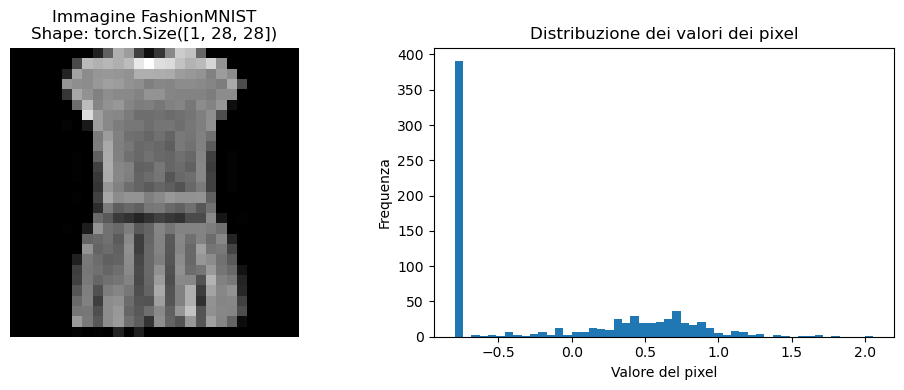

In [146]:
# Get a few sample images
sample_images = []
for i in range(5):  # Prendi 5 immagini di esempio
    image, _ = train_dataset[i]
    sample_images.append(image)

# Display information about the images
for i, image in enumerate(sample_images):
    print(f"Immagine {i+1}:")
    print(f"  Forma (shape): {image.shape}")
    print(f"  Tipo di dati: {image.dtype}")
    print(f"  Valore minimo: {image.min().item()}")
    print(f"  Valore massimo: {image.max().item()}")
    print()

# Visualize one image to see the channels
sample_image = sample_images[3]

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Immagine FashionMNIST\nShape: {sample_image.shape}")
plt.axis('off')

# Visualize the histogram of pixel values
plt.subplot(122)
plt.hist(sample_image.numpy().flatten(), bins=50)
plt.title("Distribuzione dei valori dei pixel")
plt.xlabel("Valore del pixel")
plt.ylabel("Frequenza")

plt.tight_layout()
plt.show()

## Creo un PyTorch Lightining DataModule for FashionMNIST

### Pipeline di trasformazione dei dati per l'addestramento


In [147]:
transform_train = transforms.Compose([
    # Effettua un flip orizzontale casuale delle immagini, aumentando così la variabilità del dataset
    # e aiutando il modello a generalizzare meglio per oggetti che possono apparire specchiati
    transforms.RandomHorizontalFlip(),
    
    # Applica una rotazione casuale fino a 10 gradi, rendendo il modello più robusto 
    # a variazioni nell'orientamento degli oggetti nelle immagini
    transforms.RandomRotation(10),
    
    # Sposta casualmente l'immagine orizzontalmente o verticalmente fino al 10% delle dimensioni,
    # migliorando la capacità del modello di riconoscere oggetti in posizioni diverse
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    
    # Converte le immagini in tensori PyTorch, prerequisito per l'elaborazione con le reti neurali
    transforms.ToTensor(),
    
    # Normalizza i dati con media 0.28 e deviazione standard 0.35, ottimizzando la convergenza
    # durante l'addestramento e standardizzando l'input per il modello
    transforms.Normalize((0.28,), (0.35,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.28,), (0.35,))
])

In [148]:
class FashionMNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="./data/", batch_size=128):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.transform_train = transform_train
        self.transform_test = transform_test
        
    def prepare_data(self):
        datasets.FashionMNIST(self.data_dir, train=True, download=True)
        datasets.FashionMNIST(self.data_dir, train=False, download=True)
        
    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            mnist_full = datasets.FashionMNIST(
                self.data_dir, train=True, transform=self.transform_train
            )
            self.fashion_train, self.fashion_val = random_split(mnist_full, [48000, 12000])
            
        if stage == 'test' or stage is None:
            self.fashion_test = datasets.FashionMNIST(
                self.data_dir, train=False, transform=self.transform_test
            )
            
    def train_dataloader(self):
        return DataLoader(self.fashion_train, batch_size=self.batch_size, shuffle=True, num_workers=4)
    
    def val_dataloader(self):
        return DataLoader(self.fashion_val, batch_size=self.batch_size, num_workers=4)
    
    def test_dataloader(self):
        return DataLoader(self.fashion_test, batch_size=self.batch_size, num_workers=4)

## Creo il modello CNN

l’input è un’immagine in scala di grigi di dimensione 28x28x1. Il passaggio attraverso i vari layer convoluzionali e di pooling trasforma progressivamente questa immagine, modificandone le dimensioni e il numero di canali:

1.	Primo blocco convoluzionale
	* conv1: La convoluzione con 32 filtri (kernel 3x3, padding=1) mantiene la dimensione spaziale 28x28, ma aumenta il numero di canali a 32.
	* conv2: Un’altra convoluzione con 64 filtri mantiene la dimensione spaziale, ma porta i canali a 64.
	* MaxPooling (2x2): Riduce le dimensioni spaziali a 14x14x64.
2.	Secondo blocco convoluzionale
	* conv3: Convoluzione con 128 filtri, mantiene la dimensione spaziale 14x14, ma aumenta i canali a 128.
	* conv4: Convoluzione con 128 filtri, mantiene la dimensione spaziale.
	* MaxPooling (2x2): Riduce le dimensioni a 7x7x128.
3.	Terzo blocco convoluzionale
	* conv5: Convoluzione con 256 filtri, mantiene la dimensione spaziale 7x7, ma aumenta i canali a 256.
	* conv6: Convoluzione con 256 filtri, mantiene la dimensione spaziale.
	* MaxPooling (2x2): Riduce le dimensioni a 3x3x256.
4.	Flattening e Fully Connected Layers
	* I dati vengono appiattiti in un vettore di dimensione 256×3×3 = 2304.
	* fc1: Un layer fully connected con 512 neuroni.
	* fc2: Un secondo layer fully connected riduce la dimensione a 256.
	* fc3: L’ultimo layer fully connected produce 10 output, uno per ogni classe dell’insieme Fashion-MNIST.

Durante il processo, i batch normalization layer stabilizzano l’allenamento, mentre i dropout layer riducono l’overfitting.

---


Nel metodo `forward`, l’input attraversa tre blocchi convoluzionali seguiti da livelli fully connected. Ogni trasformazione modifica la forma dei dati come segue:

1.	Input
* L’input è un batch di immagini di dimensione (batch_size, 1, 28, 28).
2.	Primo blocco convoluzionale
* conv1: Applica 32 filtri (3x3) → la dimensione rimane (batch_size, 32, 28, 28).
* bn1: Normalizzazione batch per stabilizzare l’allenamento.
* ReLU: Attivazione non lineare.
* conv2: Applica 64 filtri (3x3) → la dimensione diventa (batch_size, 64, 28, 28).
* bn2 e ReLU: Normalizzazione e attivazione.
* MaxPool(2,2): Riduce la dimensione spaziale a (batch_size, 64, 14, 14).
* Dropout(0.25): Riduce l’overfitting.
3.	Secondo blocco convoluzionale
* conv3: Applica 128 filtri (3x3) → la dimensione diventa (batch_size, 128, 14, 14).
* bn3 e ReLU.
* conv4: Applica 128 filtri (3x3) → la dimensione rimane (batch_size, 128, 14, 14).
* bn4 e ReLU.
* MaxPool(2,2): Riduce la dimensione spaziale a (batch_size, 128, 7, 7).
* Dropout(0.25).
4.	Terzo blocco convoluzionale
* conv5: Applica 256 filtri (3x3) → la dimensione diventa (batch_size, 256, 7, 7).
* bn5 e ReLU.
* conv6: Applica 256 filtri (3x3) → la dimensione rimane (batch_size, 256, 7, 7).
* bn6 e ReLU.
* MaxPool(2,2): Riduce la dimensione spaziale a (batch_size, 256, 3, 3).
5.	Appiattimento e Fully Connected Layers
* x.view(x.size(0), -1): Trasforma (batch_size, 256, 3, 3) in (batch_size, 2304).
* fc1: Layer fully connected con 512 neuroni → (batch_size, 512).
* bn_fc1, ReLU e Dropout(0.4).
* fc2: Layer fully connected con 256 neuroni → (batch_size, 256).
* bn_fc2 e ReLU.
* fc3: Layer finale con 10 output per le classi Fashion-MNIST → (batch_size, 10).

Il risultato finale è un vettore di dimensione (batch_size, 10), che rappresenta le probabilità non normalizzate per ciascuna classe.

In [165]:
class MNISTClassifierFashion(pl.LightningModule):
    def __init__(self, hidden_size=512, learning_rate=0.0005):
        super().__init__()
        self.save_hyperparameters()
        
        # Prima serie di blocchi convoluzionali
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Seconda serie di blocchi convoluzionali
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        
        # Terza serie di blocchi convoluzionali
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        
        # Pooling e dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.5)
        
        # Calcoliamo la dimensione dopo tutti i layer convoluzionali e pooling
        # Input: 28x28 -> dopo 3 max pooling: 3x3
        self.fc_input_size = 256 * 3 * 3
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.fc_input_size, hidden_size)
        self.bn_fc1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn_fc2 = nn.BatchNorm1d(hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 10)

        
        
    def forward(self, x):
        # Input: (batch_size, 1, 28, 28) - Immagini in scala di grigi con un solo canale

        # Primo blocco: Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool -> Dropout
        x = F.relu(self.bn1(self.conv1(x)))  # (batch_size, 32, 28, 28) - Conv2d(1, 32, 3, padding=1) mantiene la dimensione
        x = F.relu(self.bn2(self.conv2(x)))  # (batch_size, 64, 28, 28) - Conv2d(32, 64, 3, padding=1) mantiene la dimensione
        x = self.pool(x)  # (batch_size, 64, 14, 14) - MaxPool2d(2,2) dimezza altezza e larghezza
        x = self.dropout1(x)  # (batch_size, 64, 14, 14) - Il dropout non cambia la forma

        # Secondo blocco
        x = F.relu(self.bn3(self.conv3(x)))  # (batch_size, 128, 14, 14) - Conv2d(64, 128, 3, padding=1) mantiene la dimensione
        x = F.relu(self.bn4(self.conv4(x)))  # (batch_size, 128, 14, 14) - Conv2d(128, 128, 3, padding=1) mantiene la dimensione
        x = self.pool(x)  # (batch_size, 128, 7, 7) - MaxPool2d(2,2) dimezza altezza e larghezza
        x = self.dropout2(x)  # (batch_size, 128, 7, 7) - Dropout non cambia la forma

        # Terzo blocco
        x = F.relu(self.bn5(self.conv5(x)))  # (batch_size, 256, 7, 7) - Conv2d(128, 256, 3, padding=1) mantiene la dimensione
        x = F.relu(self.bn6(self.conv6(x)))  # (batch_size, 256, 7, 7) - Conv2d(256, 256, 3, padding=1) mantiene la dimensione
        x = self.pool(x)  # (batch_size, 256, 3, 3) - MaxPool2d(2,2) dimezza altezza e larghezza

        # Appiattimento e fully connected
        x = x.view(x.size(0), -1)  # (batch_size, 256 * 3 * 3) → (batch_size, 2304)
        x = F.relu(self.bn_fc1(self.fc1(x)))  # (batch_size, hidden_size) - hidden_size di default è 512
        x = self.dropout3(x)  # (batch_size, hidden_size) - Dropout non cambia la forma
        x = F.relu(self.bn_fc2(self.fc2(x)))  # (batch_size, hidden_size//2) - hidden_size//2 è 256
        x = self.fc3(x)  # (batch_size, 10) - 10 classi di output per FashionMNIST

        return x 
    
    def training_step(self, batch, batch_idx):
        x, y = batch # Riceve un batch di dati
        logits = self(x) # Propaga x attraverso il modello (self(x)) per ottenere i logits (output non normalizzati).
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1) # Estrae le predizioni con torch.argmax(logits, dim=1), scegliendo la classe con la probabilità più alta.
        acc = (preds == y).float().mean() # confronta le predizioni con i target per calcolare l’accuracy media
        
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)
        return {"test_loss": loss, "test_acc": acc, "preds": preds, "targets": y}
     
    # ipotesi  con ReduceLRonPlateau
    def configure_optimizers(self): 
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.learning_rate,
            weight_decay=1e-4
            
        )
        
        # Scheduler che riduce il learning rate quando l'accuracy smette di migliorare
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5, # dimezza il learning rate se val_loss non mi glioria
            patience=3,
            verbose=True
        )
        
       
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }
    """   
    ipotesi  con OneCycleLR
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.learning_rate,
            weight_decay=5e-5
        )

        # Ricaviamo il numero di step per epoca (se il trainer esiste e ha un dataloader)
        if self.trainer is not None and self.trainer.train_dataloader is not None:
            steps_per_epoch = len(self.trainer.train_dataloader)
        else:
            steps_per_epoch = 1000  # Valore di fallback (da adattare in base al dataset)

        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, 
            max_lr=self.hparams.learning_rate * 10,
            steps_per_epoch=steps_per_epoch,  
            epochs=self.trainer.max_epochs if self.trainer is not None else 30,  # Fallback a 30 epoche
            anneal_strategy="cos",
            pct_start=0.3
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
            "scheduler": scheduler,
            "interval": "step",
            }
        }
      """


## Alleno il modello

In [166]:
# Create data module with consistent batch size
data_module = FashionMNISTDataModule(batch_size=128)

# Define a function to train and evaluate a model
def train_and_evaluate(model, model_name, max_epochs=30):
    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        verbose=True,
        mode='min'
    )
    
    # Checkpoint callback per salvare il miglior modello
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        dirpath='./checkpoints/',
        filename=f'{model_name}-{{epoch:02d}}-{{val_acc:.4f}}',
        save_top_k=1,
        mode='max'
    )
    
    # LR Monitor
    lr_monitor = LearningRateMonitor(logging_interval='epoch')
    
    # Trainer
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        callbacks=[early_stopping, checkpoint_callback, lr_monitor],
        accelerator='auto',
        devices="auto",  # Usiamo "auto" invece di None
        logger=True,
    )
    
    # Training
    print(f"\nTraining {model_name}...")
    trainer.fit(model, data_module)
    
    # Load best model
    best_model_path = checkpoint_callback.best_model_path
    if best_model_path:
        print(f"Loading best model from {best_model_path}")
        model = type(model).load_from_checkpoint(best_model_path)
    
    # Testing
    print(f"\nTesting {model_name}...")
    test_results = trainer.test(model, data_module)
    
    return model, test_results

In [167]:
# Train and evaluate the CNN model
cnn_model_fashion = MNISTClassifierFashion(learning_rate=0.0005)
cnn_model_fashion, cnn_results_fashion = train_and_evaluate(cnn_model_fashion, "CNN Model Fashion", max_epochs=30)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Training CNN Model Fashion...



   | Name     | Type        | Params | Mode 
--------------------------------------------------
0  | conv1    | Conv2d      | 320    | train
1  | bn1      | BatchNorm2d | 64     | train
2  | conv2    | Conv2d      | 18.5 K | train
3  | bn2      | BatchNorm2d | 128    | train
4  | conv3    | Conv2d      | 73.9 K | train
5  | bn3      | BatchNorm2d | 256    | train
6  | conv4    | Conv2d      | 147 K  | train
7  | bn4      | BatchNorm2d | 256    | train
8  | conv5    | Conv2d      | 295 K  | train
9  | bn5      | BatchNorm2d | 512    | train
10 | conv6    | Conv2d      | 590 K  | train
11 | bn6      | BatchNorm2d | 512    | train
12 | pool     | MaxPool2d   | 0      | train
13 | dropout1 | Dropout     | 0      | train
14 | dropout2 | Dropout     | 0      | train
15 | dropout3 | Dropout     | 0      | train
16 | fc1      | Linear      | 1.2 M  | train
17 | bn_fc1   | BatchNorm1d | 1.0 K  | train
18 | fc2      | Linear      | 131 K  | train
19 | bn_fc2   | BatchNorm1d | 512    | train
20 

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

Training: |                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Loading best model from /Users/pandagan/workspace/projects/cb-ai/ai-bootcamp-2025/ml_ai/lecture_5/checkpoints/CNN Model Fashion-epoch=29-val_acc=0.9355.ckpt

Testing CNN Model Fashion...


Testing: |                                                | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.941100001335144
        test_loss           0.17127926647663116
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [168]:
from torchsummary import summary
print("\nCNN Model Summary:")
summary(cnn_model_fashion, input_size=(1, 28, 28))


CNN Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
            Conv2d-3           [-1, 64, 28, 28]          18,496
       BatchNorm2d-4           [-1, 64, 28, 28]             128
         MaxPool2d-5           [-1, 64, 14, 14]               0
           Dropout-6           [-1, 64, 14, 14]               0
            Conv2d-7          [-1, 128, 14, 14]          73,856
       BatchNorm2d-8          [-1, 128, 14, 14]             256
            Conv2d-9          [-1, 128, 14, 14]         147,584
      BatchNorm2d-10          [-1, 128, 14, 14]             256
        MaxPool2d-11            [-1, 128, 7, 7]               0
          Dropout-12            [-1, 128, 7, 7]               0
           Conv2d-13            [-1, 256, 7, 7]         295,168
      BatchNorm2d-1

In [169]:
# Funzione per salvare il modello
def save_model(model, path="./saved_models/fashion_mnist_model.pt"):
    import os
    
    # Crea la directory se non esiste
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    # Salva il modello completo
    torch.save(model, path)
    print(f"Modello salvato in {path}")
    
    # Salva anche solo i parametri (più portabile)
    state_dict_path = path.replace(".pt", "_state_dict.pt")
    torch.save(model.state_dict(), state_dict_path)
    print(f"State dict salvato in {state_dict_path}")
    
    return path

# E per caricarlo successivamente:
def load_model(path="./saved_models/fashion_mnist_model.pt", state_dict_only=False):
    if state_dict_only:
        # Se vogliamo caricare solo i parametri
        # Prima dobbiamo istanziare il modello
        model = ImprovedFashionMNISTClassifier()
        state_dict_path = path.replace(".pt", "_state_dict.pt")
        model.load_state_dict(torch.load(state_dict_path))
        return model
    else:
        # Carica il modello completo
        model = torch.load(path)
        return model

In [170]:
# Salva il modello
model_path = save_model(cnn_model_fashion)

# Successivamente, per usare il modello:
# loaded_model = load_model(model_path)

Modello salvato in ./saved_models/fashion_mnist_model.pt
State dict salvato in ./saved_models/fashion_mnist_model_state_dict.pt


In [171]:
def show_predictions(model, num_samples=30):

    # Get a batch of test data
    test_loader = data_module.test_dataloader()
    batch = next(iter(test_loader))
    images, labels = batch
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
    
    # Plot images with predictions
    fig, axes = plt.subplots(6, 5, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < min(len(images), 30):  # Make sure we don't go out of bounds
            img = images[i].squeeze().cpu().numpy()
            label_idx = labels[i].item()
            pred_idx = preds[i].item()
            
            # Get the text labels
            true_label = fashion_labels[label_idx]
            pred_label = fashion_labels[pred_idx]
            
            ax.imshow(img, cmap='gray')
            title_color = 'green' if pred_idx == label_idx else 'red'
            ax.set_title(f'True: {true_label} ({label_idx})\nPred: {pred_label} ({pred_idx})', 
                         color=title_color, fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

CNN Model Predictions:


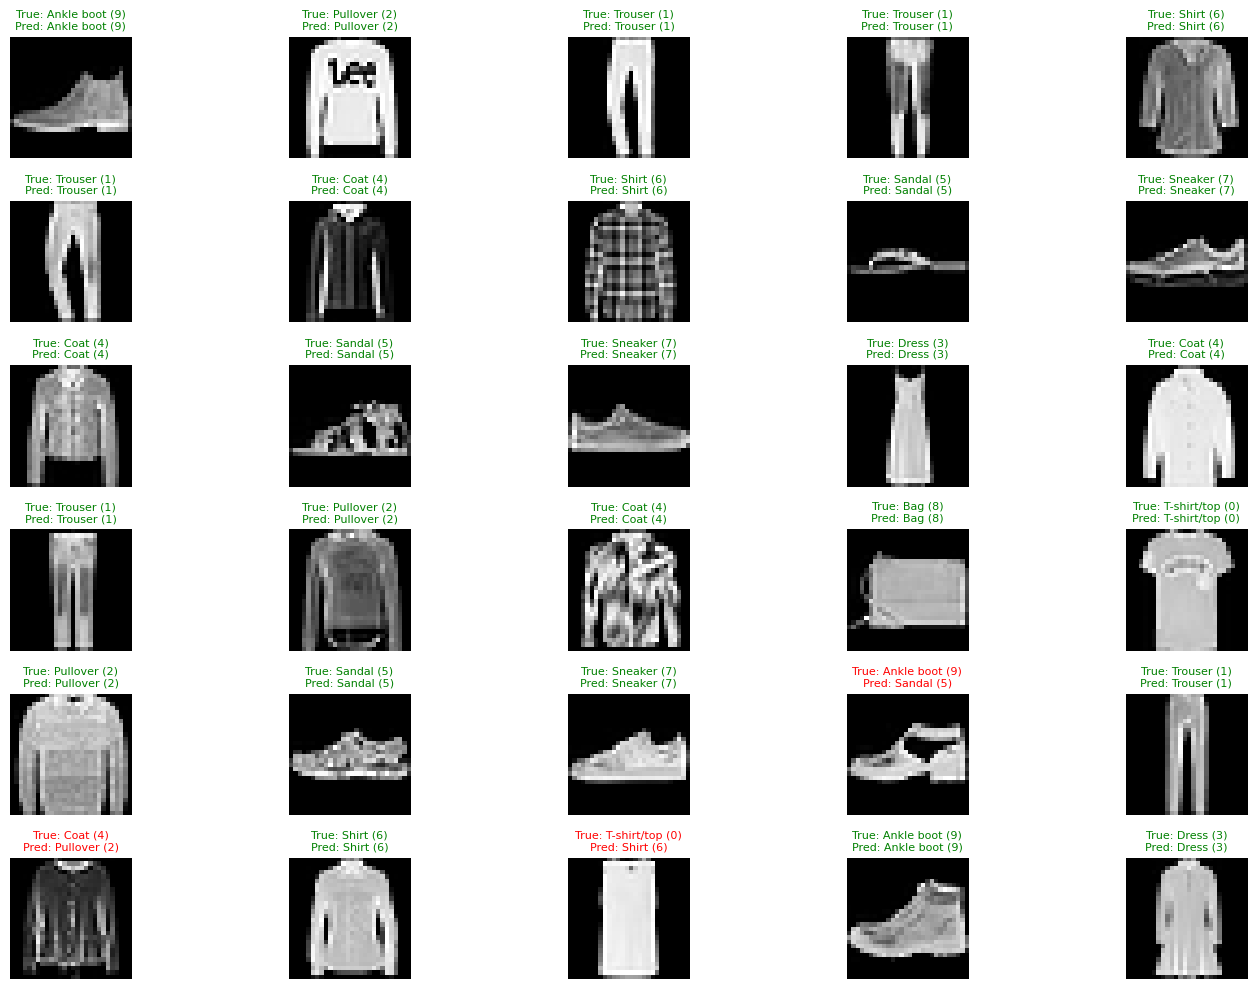

In [172]:
# Show predictions from CNN model
print("CNN Model Predictions:")
show_predictions(cnn_model_fashion)

## Compare results with digits model

In [173]:
# Print result comparison
print("-" * 50)
print("Model Comparison on MNIST Test Set:")
print("-" * 50)
print(f"CNN Model Digits - Accuracy: 0.9873, Loss: 0.0418")
print(f"CNN Model Fashion - Accuracy: {cnn_results_fashion[0]['test_acc']:.4f}, Loss: {cnn_results_fashion[0]['test_loss']:.4f}")
print("-" * 50)



--------------------------------------------------
Model Comparison on MNIST Test Set:
--------------------------------------------------
CNN Model Digits - Accuracy: 0.9873, Loss: 0.0418
CNN Model Fashion - Accuracy: 0.9411, Loss: 0.1713
--------------------------------------------------
